# US Births Data Analysis with ARIMA Modeling
## Complete Time Series Analysis Pipeline

This notebook uses the utilities module for comprehensive time series analysis including:
1. Data loading and exploration
2. Descriptive visualizations
3. **ACF/PACF analysis**
4. **Stationarity testing**
5. **ARIMA model grid search**
6. **Model evaluation and forecasting**

In [1]:
# Standard imports
from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import US births analysis module
import utilities.us_births_analysis as births

# Import ARIMA analysis module
import utilities.arima_analysis as arima

# Or use direct imports from utilities
# from utilities import (
#     analyze_births_data,
#     plot_acf_pacf,
#     check_stationarity,
#     arima_grid_search,
#     plot_residual_diagnostics,
#     plot_forecast
# )

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

print("✓ All imports successful")

✓ All imports successful


## 1. Load and Prepare Data

In [2]:
# Load dataset
ds = load_dataset("thuml/UTSD", "UTSD-1G")
df = pd.DataFrame(ds['train'])
con = ddb.connect()

# Filter for US births data
us_births_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%birth%';
""").fetch_df()

print(f"Found {len(us_births_df)} US births time series")

# Get the data row
row = us_births_df.iloc[0]

# Run complete analysis using births module
results = births.analyze_births_data(row)

# Extract results
births_df = results['births_df']
monthly_stats = results['monthly_stats']
yearly_stats = results['yearly_stats']

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Found 1 US births time series
US BIRTHS DATA ANALYSIS

Step 1: Detecting time interval...

Time Series Information:
  Start: 1969-01-01 00:00:00
  End: 1988-12-31 00:00:00
  Duration: 7304 days 00:00:00
  Data points: 7,305
  Interval: 1.0d
  Frequency (pandas): 1D
  Frequency (dataset): 'D'

Step 2: Expanding time series...
  Created DataFrame with 7,305 rows

Step 3: Calculating statistics...
  Generated monthly statistics for 240 months
  Generated yearly statistics for 20 years

Overall Statistics:
  Mean births/day: 9648.94
  Median births/day: 9622.00
  Std dev: 1127.32
  Min births/day: 6675
  Max births/day: 12851
  Total births: 70,485,508

Day of Week Analysis:
  Monday: 9944 avg births
  Tuesday: 10368 avg births
  Wednesday: 10089 avg births
  Thursday: 9995 avg births
  Friday: 10147 avg births
  Saturday: 8708 avg births
  Sunday: 8290 avg births

Weekday vs Weekend:
  Weekday average: 10109
  Weekend average: 8500
  Difference: 1609 (18.9%)

Monthly Patterns:
  Highest: 

## 2. Basic Visualizations

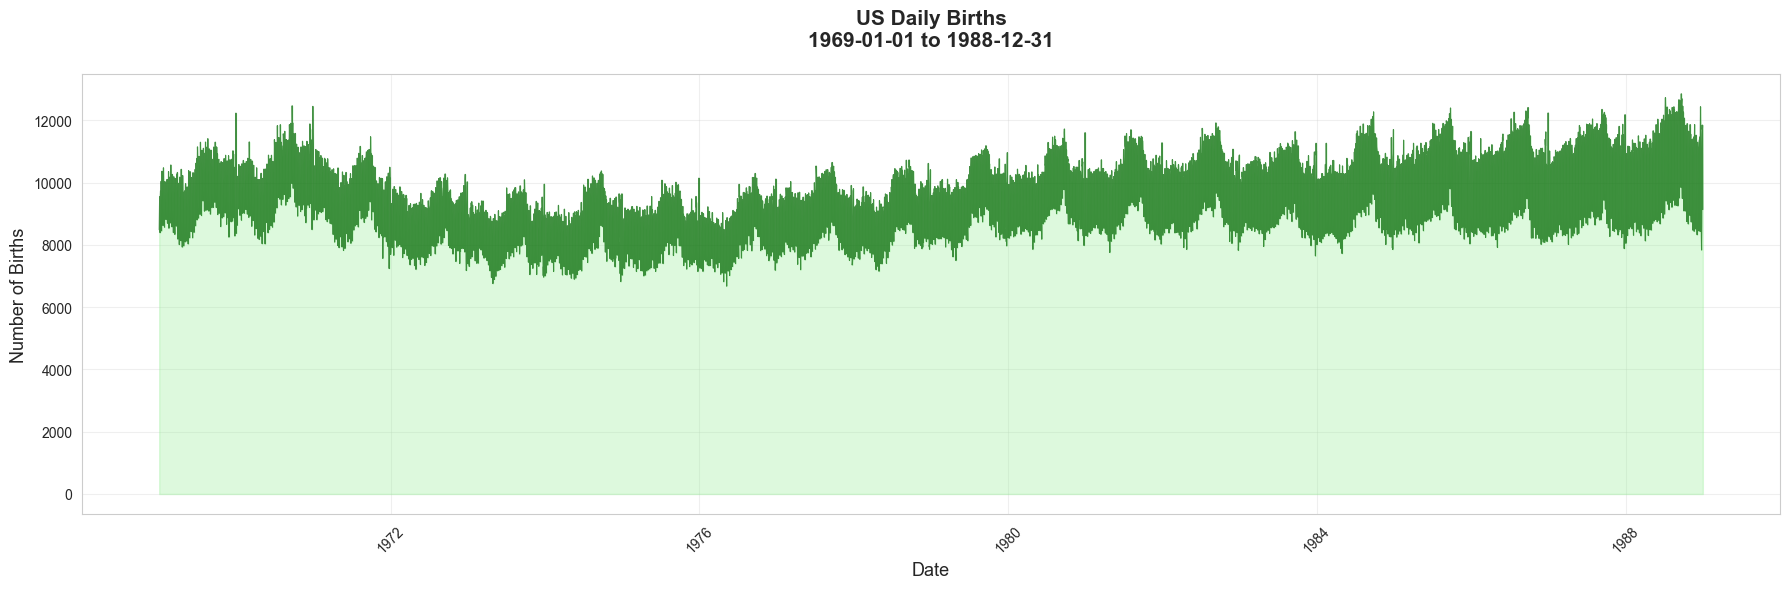

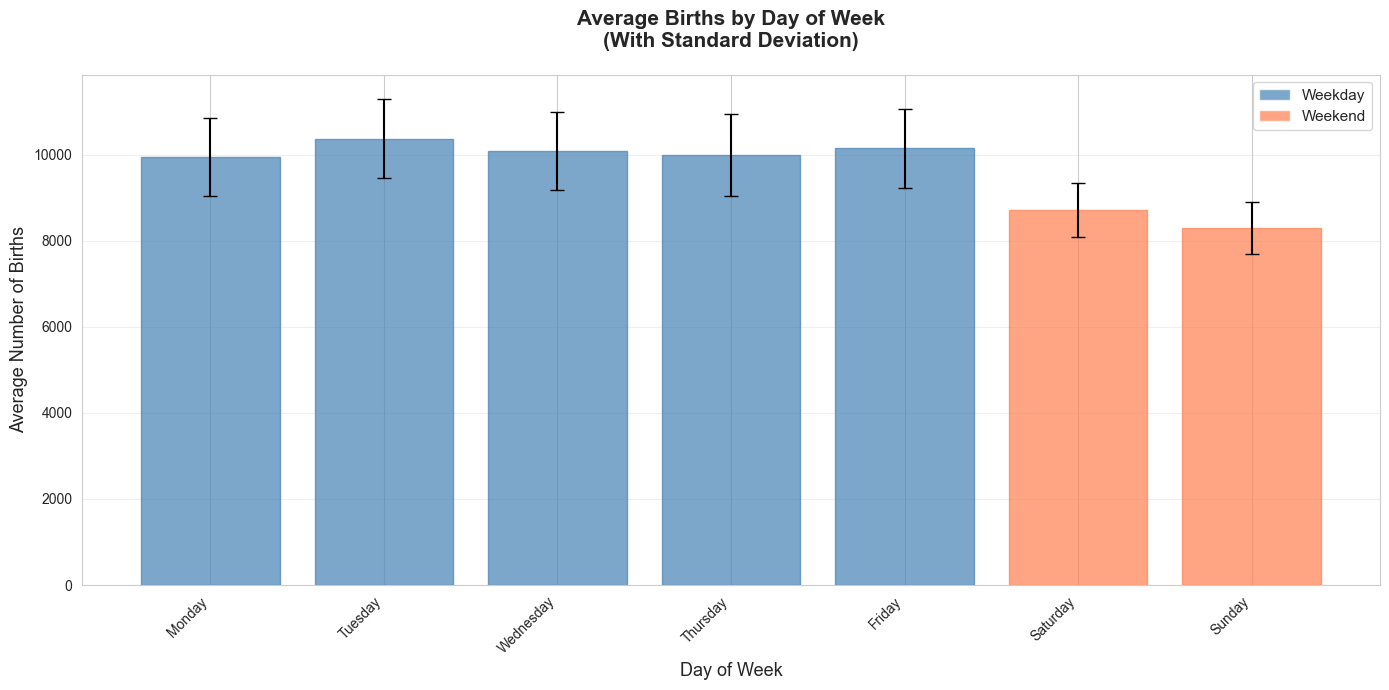

In [3]:
# Full time series
fig = births.plot_full_timeseries(births_df)
plt.show()

# Day of week patterns
fig = births.plot_day_of_week_patterns(births_df)
plt.show()

## 3. ACF and PACF Analysis

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) help us identify:
- **ACF**: Shows correlation with lagged values
- **PACF**: Shows correlation with lagged values after removing effects of intermediate lags
- These plots help determine ARIMA parameters (p, d, q)

ACF and PACF Analysis for Daily Births


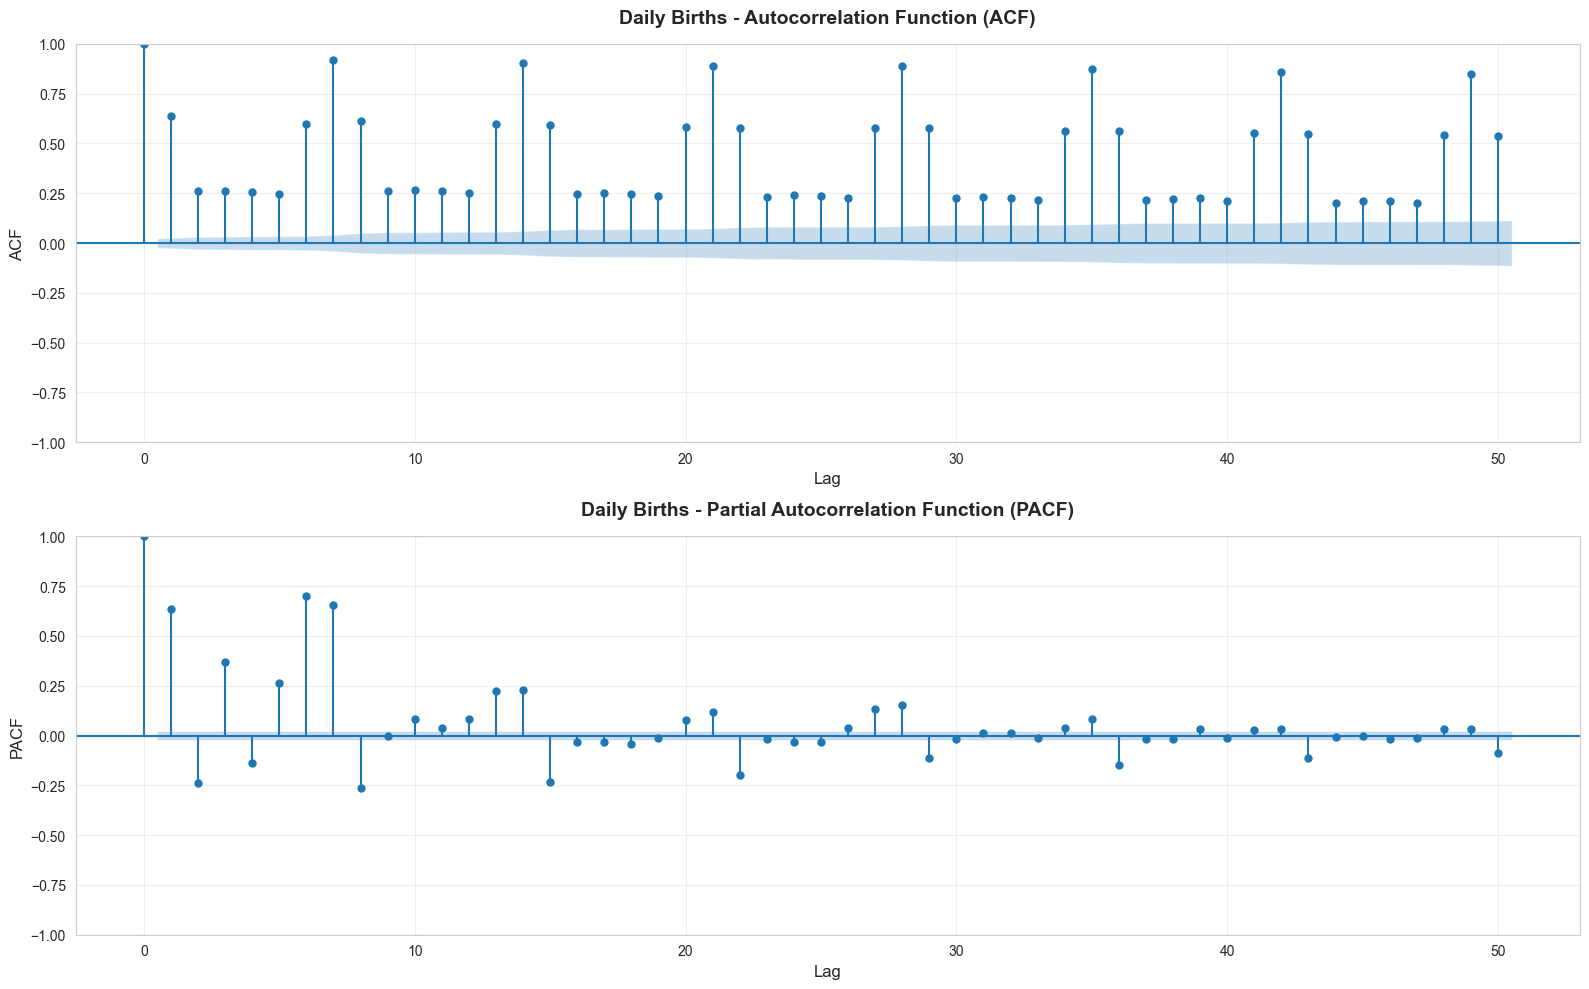

In [4]:
print("ACF and PACF Analysis for Daily Births")
print("=" * 70)

# Plot ACF and PACF for original series using arima module
fig = arima.plot_acf_pacf(births_df['births'].values, lags=50,
                          title_prefix="Daily Births - ")
plt.show()

## 4. Stationarity Testing

Use Augmented Dickey-Fuller (ADF) test to check if the series is stationary.
- **Stationary**: Mean and variance are constant over time
- **Non-stationary**: Requires differencing (parameter 'd' in ARIMA)

In [5]:
# Test stationarity of original series using arima module
stationarity_result = arima.check_stationarity(
    births_df['births'].values,
    name="Daily Births"
)


Augmented Dickey-Fuller Test for Daily Births
------------------------------------------------------------
ADF Statistic: -3.351550
p-value: 0.012726
Number of Lags Used: 36
Number of Observations: 7268

Critical Values:
  1%: -3.431
  5%: -2.862
  10%: -2.567

✓ Result: Series is STATIONARY (p-value = 0.012726 <= 0.05)
  → Reject null hypothesis (series has no unit root)


## 5. Differencing (If Needed)

If the series is non-stationary, apply differencing to make it stationary.

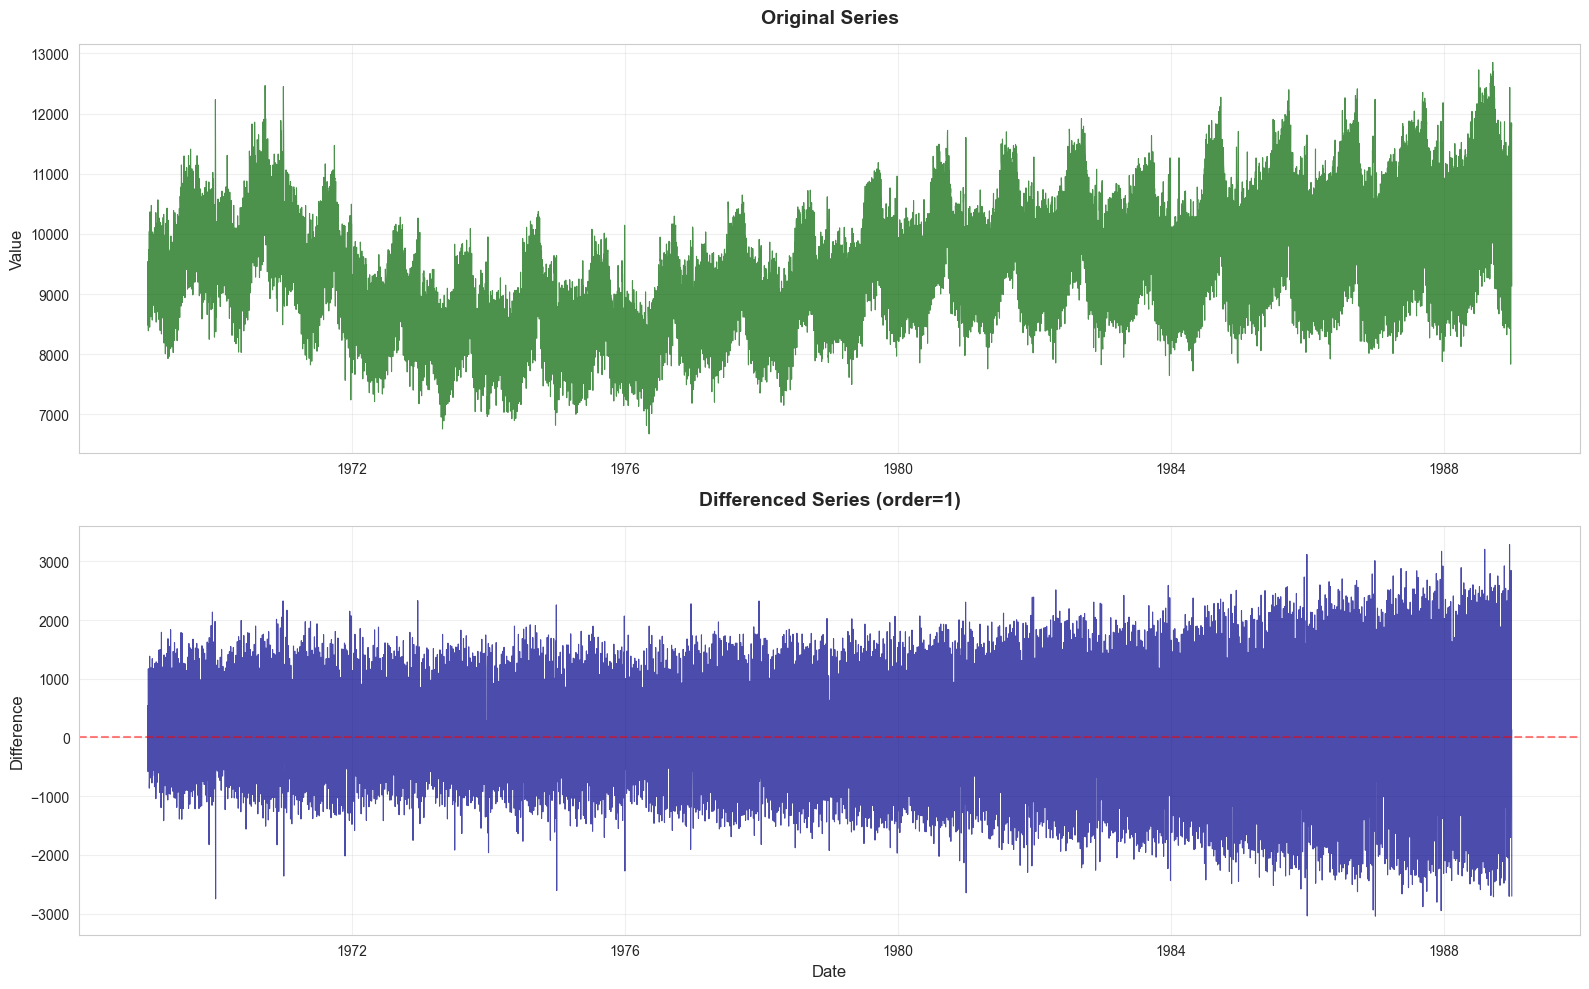



Augmented Dickey-Fuller Test for First Differenced Series
------------------------------------------------------------
ADF Statistic: -16.231887
p-value: 0.000000
Number of Lags Used: 35
Number of Observations: 7268

Critical Values:
  1%: -3.431
  5%: -2.862
  10%: -2.567

✓ Result: Series is STATIONARY (p-value = 0.000000 <= 0.05)
  → Reject null hypothesis (series has no unit root)


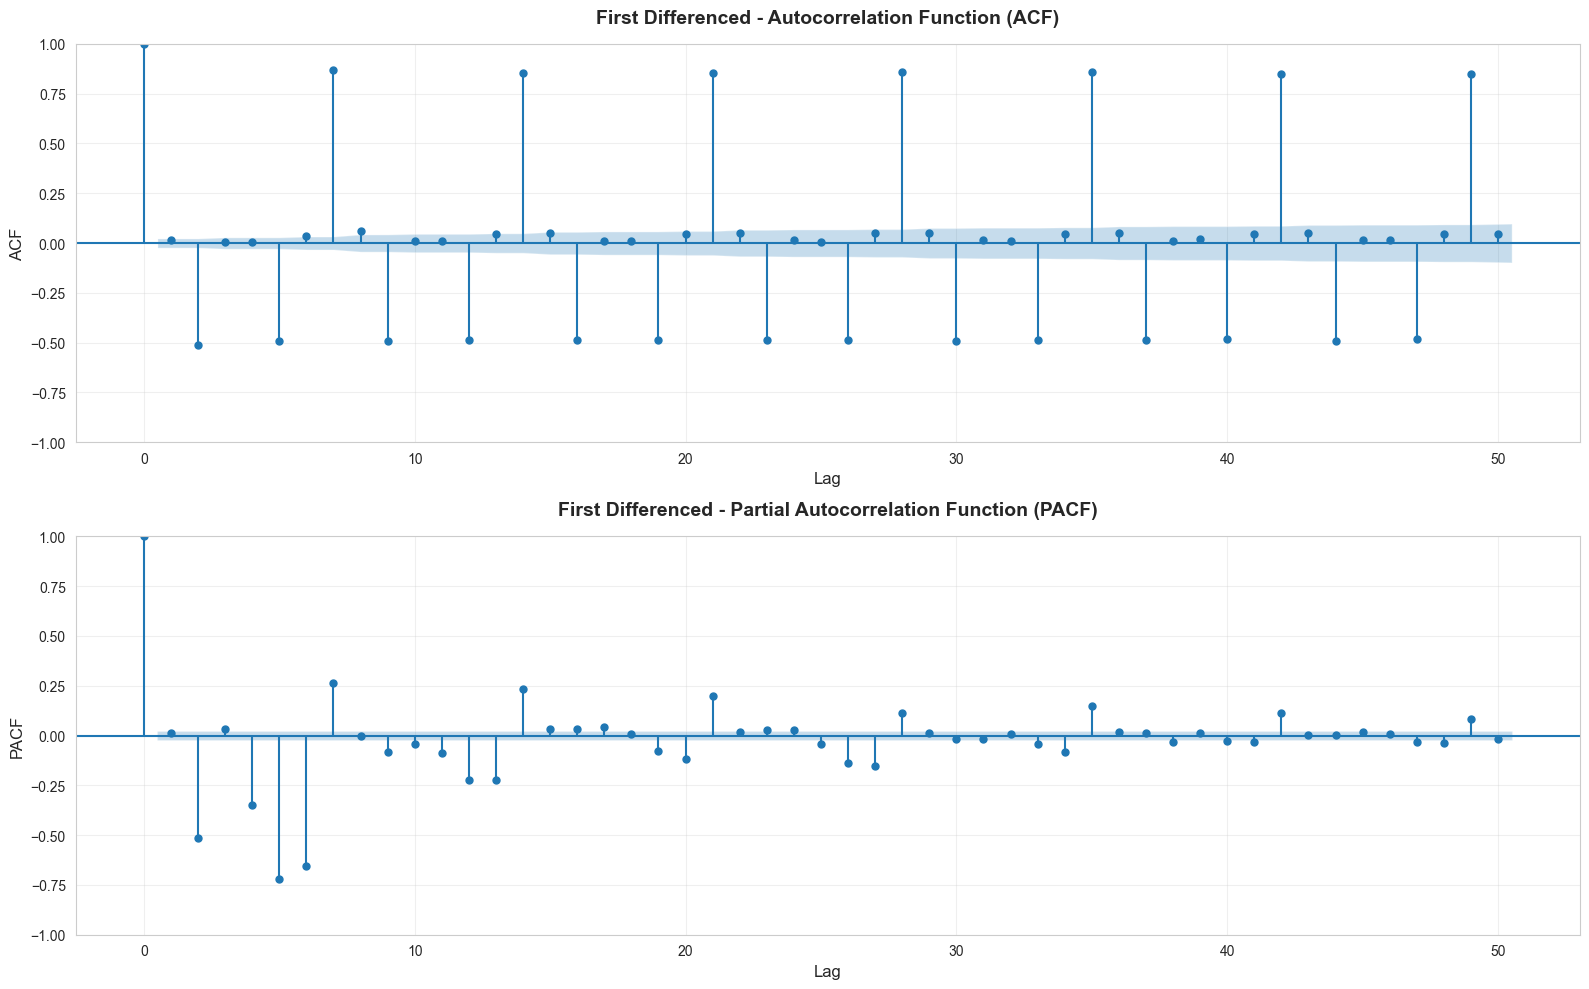

In [6]:
# Plot original vs differenced using arima module
fig, births_diff1 = arima.plot_differenced_series(
    births_df['births'],
    births_df['datetime'],
    order=1
)
plt.show()

# Check stationarity of differenced series
print("\n" + "="*70)
stationarity_diff1 = arima.check_stationarity(
    births_diff1.values,
    name="First Differenced Series"
)

# ACF/PACF of differenced series
fig = arima.plot_acf_pacf(births_diff1.values, lags=50,
                          title_prefix="First Differenced - ")
plt.show()

## 6. ARIMA Grid Search

Search through multiple ARIMA(p,d,q) combinations to find the best model.
- **p**: Order of autoregressive (AR) part
- **d**: Degree of differencing
- **q**: Order of moving average (MA) part

We'll use AIC (Akaike Information Criterion) to select the best model.

In [7]:
# Define parameter ranges
p_values = range(0, 5)  # AR order: 0 to 4
d_values = range(0, 3)  # Differencing: 0 to 2
q_values = range(0, 5)  # MA order: 0 to 4

# Run grid search using arima module
print("\nSearching for best ARIMA model...")
arima_results = arima.arima_grid_search(
    births_df['births'].values,
    p_range=p_values,
    d_range=d_values,
    q_range=q_values,
    verbose=True
)

# Display top 10 models
print("\n" + "=" * 70)
print("TOP 10 ARIMA MODELS (sorted by AIC)")
print("=" * 70)
print(arima_results.head(10).to_string(index=True))

# Display best model
best_model = arima_results.iloc[0]
print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)
print(f"ARIMA({int(best_model['p'])}, {int(best_model['d'])}, {int(best_model['q'])})")
print(f"  AIC:  {best_model['AIC']:.2f}")
print(f"  BIC:  {best_model['BIC']:.2f}")
print(f"  HQIC: {best_model['HQIC']:.2f}")
print("=" * 70)


Searching for best ARIMA model...
Testing 75 ARIMA models...
Progress: 10/75 models tested...
Progress: 20/75 models tested...
Progress: 30/75 models tested...
Progress: 40/75 models tested...
Progress: 50/75 models tested...
Progress: 60/75 models tested...
Progress: 70/75 models tested...

✓ Grid search complete! Tested 75 successful models

TOP 10 ARIMA MODELS (sorted by AIC)
   p  d  q            AIC            BIC           HQIC  log_likelihood
0  4  1  3  110816.561332  110871.730751  110835.531278   -55400.280666
1  4  1  4  111242.391467  111304.457064  111263.732658   -55612.195734
2  4  1  2  111830.655127  111878.928369  111847.253830   -55908.327563
3  4  1  1  113869.868800  113911.245864  113884.096260   -56928.934400
4  4  0  4  114263.925778  114332.888921  114287.638519   -57121.962889
5  4  0  2  114323.052762  114378.223276  114342.022955   -57153.526381
6  4  0  3  114557.338305  114619.405134  114578.679773   -57269.669153
7  3  1  4  114674.079756  114729.249175 

## 7. Fit and Evaluate Best Model

In [8]:
# Import ARIMA from statsmodels
from statsmodels.tsa.arima.model import ARIMA  # type: ignore

# Fit the best ARIMA model
best_p = int(arima_results.iloc[0]['p'])
best_d = int(arima_results.iloc[0]['d'])
best_q = int(arima_results.iloc[0]['q'])

print(f"Fitting ARIMA({best_p}, {best_d}, {best_q}) model...")
best_arima_model = ARIMA(births_df['births'].values,
                         order=(best_p, best_d, best_q))
best_fitted = best_arima_model.fit()

# Print model summary
print("\n" + "=" * 70)
print(f"ARIMA({best_p}, {best_d}, {best_q}) MODEL SUMMARY")
print("=" * 70)
print(best_fitted.summary())

Fitting ARIMA(4, 1, 3) model...

ARIMA(4, 1, 3) MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 7305
Model:                 ARIMA(4, 1, 3)   Log Likelihood              -55400.281
Date:                Tue, 28 Oct 2025   AIC                         110816.561
Time:                        20:16:10   BIC                         110871.731
Sample:                             0   HQIC                        110835.531
                               - 7305                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8318      0.013     65.786      0.000       0.807       0.857
ar.L2         -1.3101      0.018    -73.275      0.000      -1.345   

## 8. Residual Diagnostics

Check if residuals are white noise (no patterns left to model).

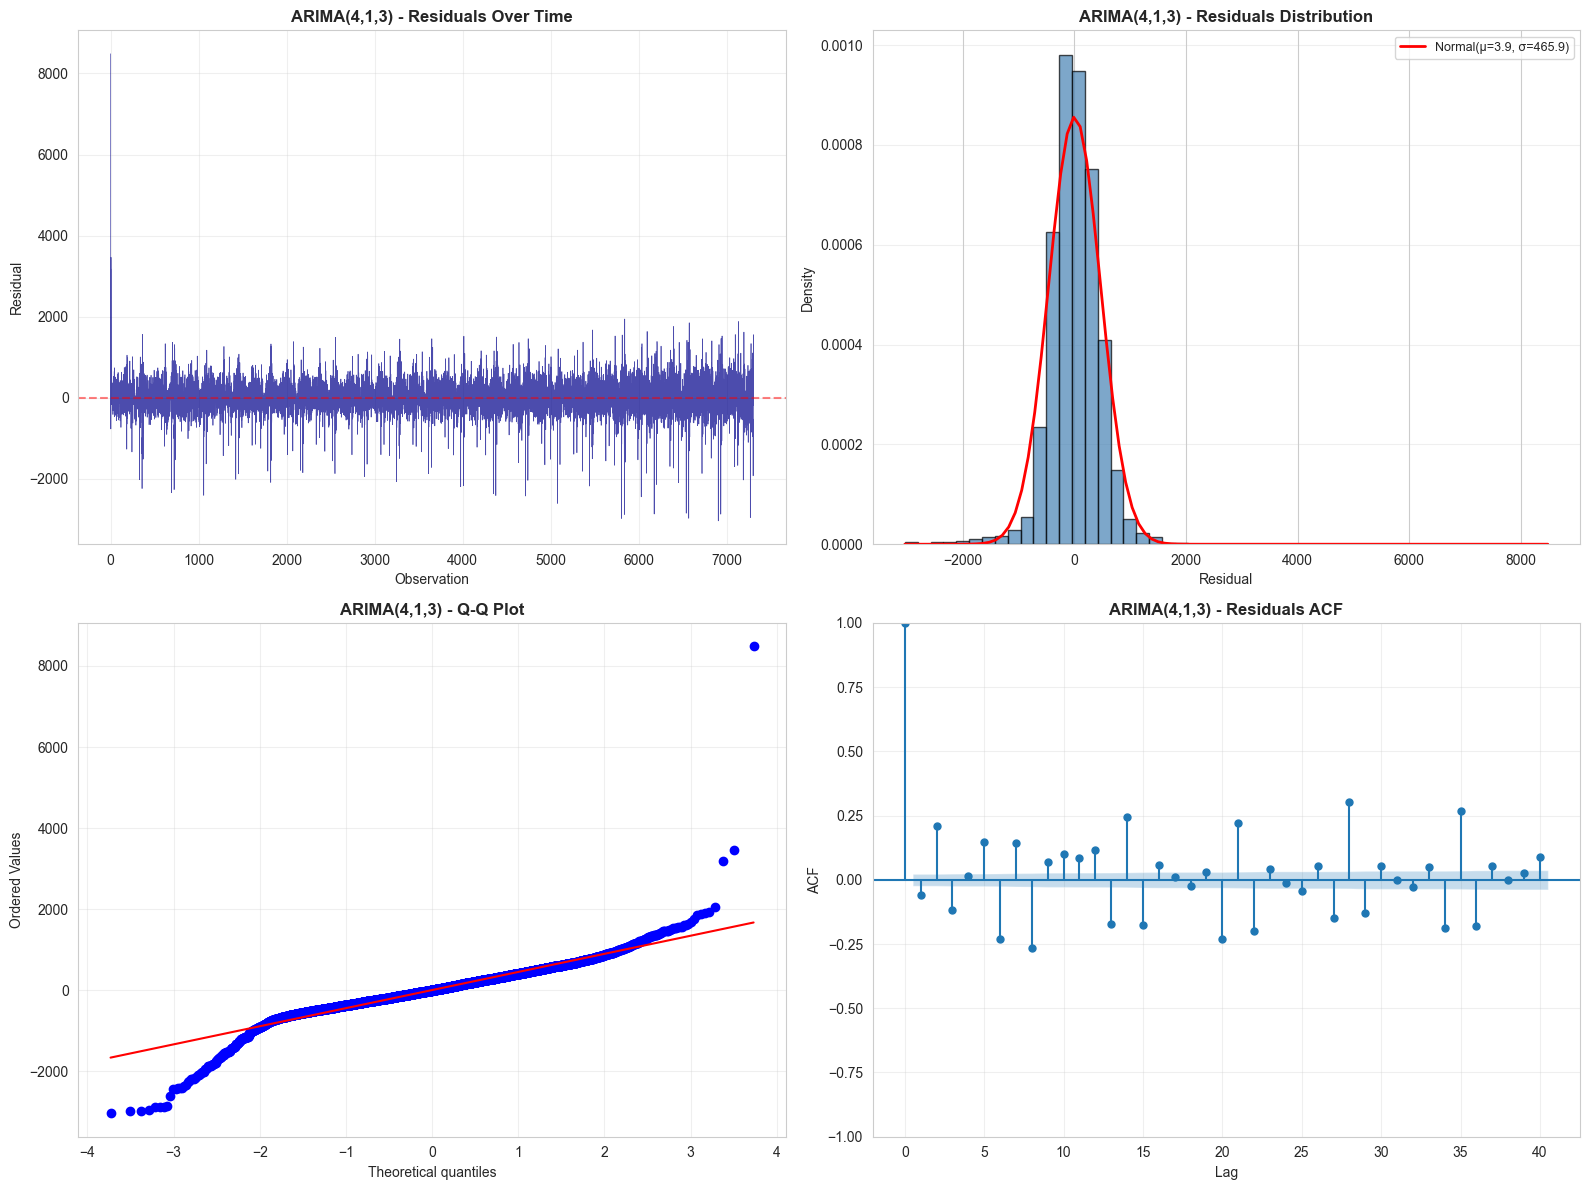


RESIDUAL DIAGNOSTICS

Residual Statistics:
  Mean: 3.853180 (should be close to 0)
  Std Dev: 465.88
  Min: -3038.97
  Max: 8486.00

Ljung-Box Test (tests for residual autocorrelation):
        lb_stat  lb_pvalue
10  1775.252344        0.0
20  3236.883396        0.0
30  4902.801553        0.0

  → If p-values > 0.05, residuals are white noise (good!)


In [9]:
# Plot diagnostics using arima module
fig = arima.plot_residual_diagnostics(
    best_fitted,
    title=f"ARIMA({best_p},{best_d},{best_q})"
)
plt.show()

# Print statistical tests using arima module
arima.print_residual_diagnostics(best_fitted)

## 9. Forecasting

Use the fitted model to forecast future births.

ValueError: x and y must have same first dimension, but have shapes (7304,) and (7305,)

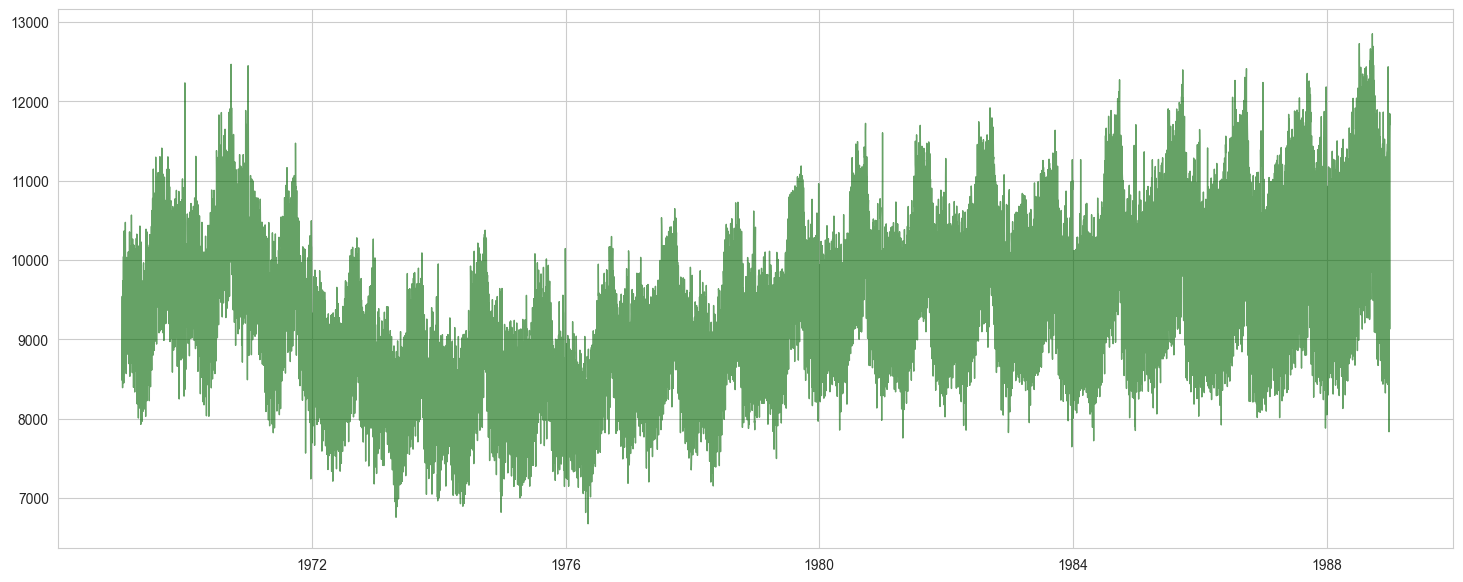

In [10]:
# Make forecast using arima module
forecast_days = 365

fig, forecast_vals, forecast_conf = arima.plot_forecast(
    births_df['births'].values,
    best_fitted,
    forecast_steps=forecast_days,
    datetime_index=births_df['datetime'],
    title=f'ARIMA({best_p},{best_d},{best_q}) Forecast: {forecast_days} Days Ahead'
)
plt.show()

# Print forecast statistics
print("\n" + "=" * 70)
print(f"FORECAST SUMMARY ({forecast_days} days ahead)")
print("=" * 70)
print(f"Average forecasted births: {forecast_vals.mean():.2f}")
print(f"Min forecasted births: {forecast_vals.min():.2f}")
print(f"Max forecasted births: {forecast_vals.max():.2f}")
print(f"Forecast std dev: {forecast_vals.std():.2f}")

## 10. Compare Top Models (Optional)


Comparing top 5 ARIMA models...


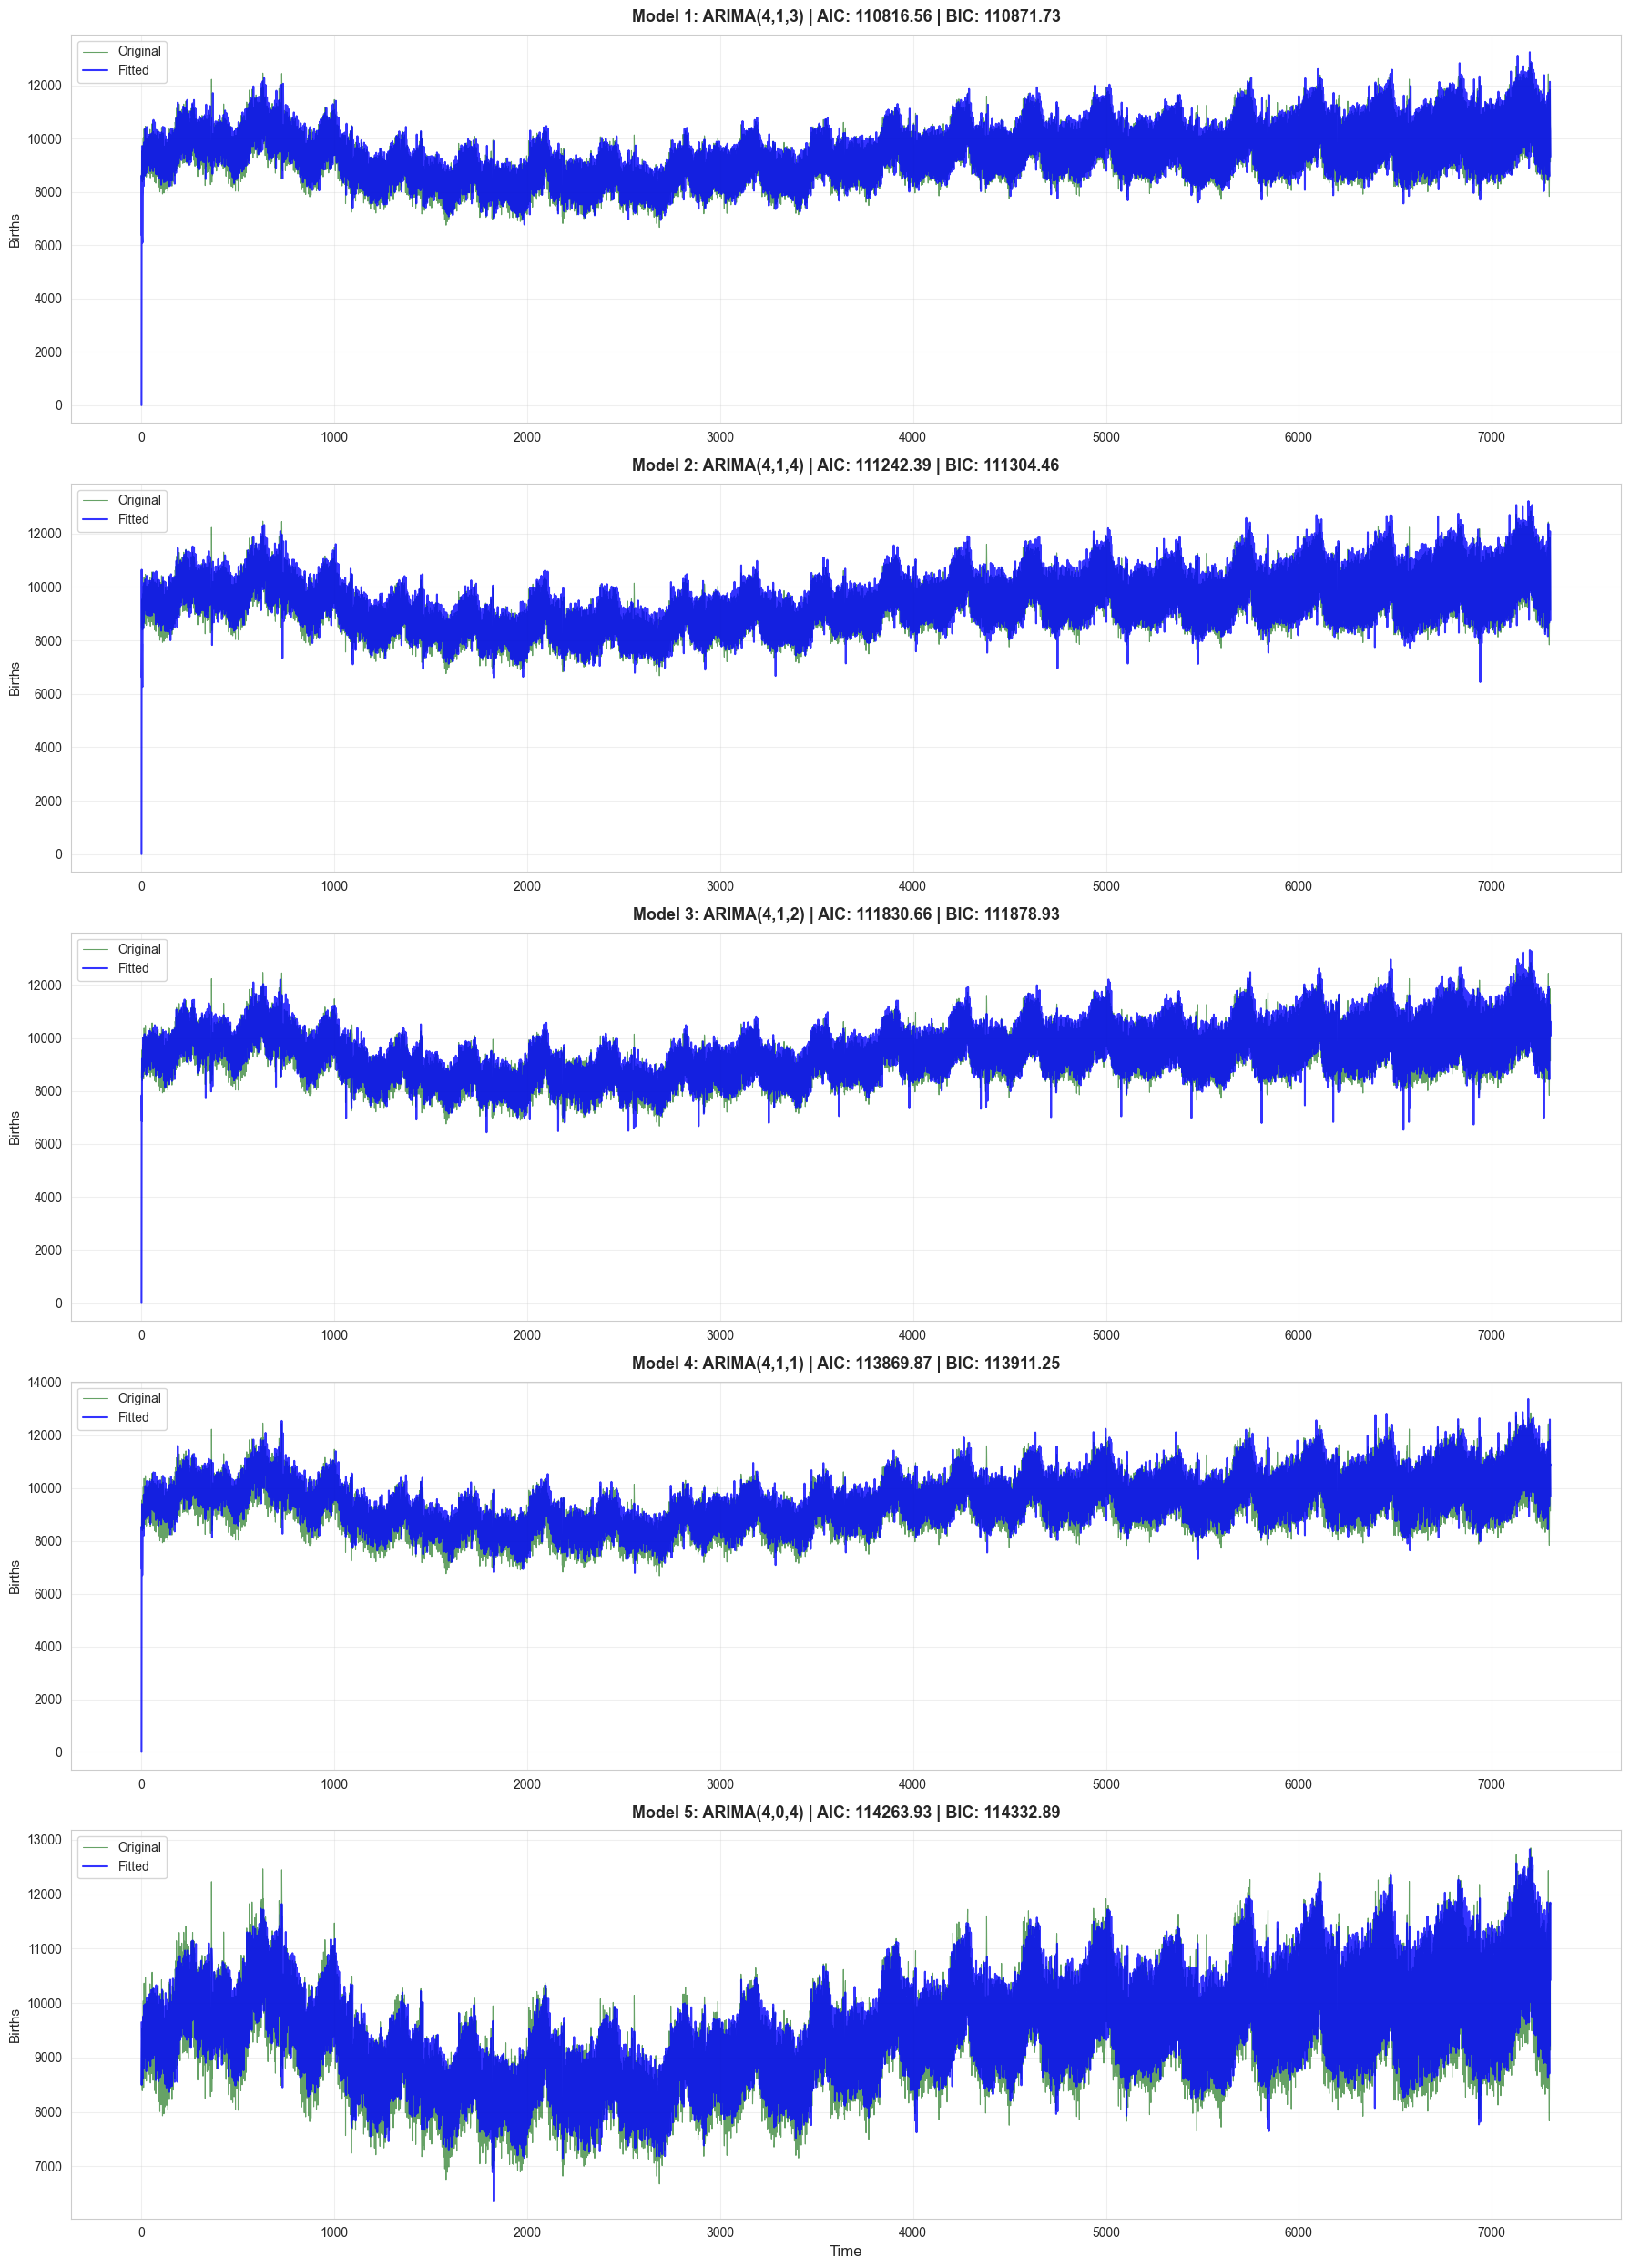

In [12]:
# Compare top 5 models visually using arima module
fig = arima.compare_top_models(
    births_df['births'].values,
    arima_results,
    top_n=5
)
plt.show()

## Summary

This notebook demonstrated:
1. ✓ Using `utilities.us_births_analysis` for data exploration
2. ✓ Using `utilities.arima_analysis` for time series modeling
3. ✓ ACF/PACF analysis for identifying patterns
4. ✓ Stationarity testing with ADF test
5. ✓ Differencing to achieve stationarity
6. ✓ Grid search across multiple ARIMA models
7. ✓ Model evaluation with AIC/BIC
8. ✓ Residual diagnostics (white noise test)
9. ✓ Forecasting with confidence intervals
10. ✓ Comparison of multiple models

**Key Takeaways:**
- All functionality is now organized in the `utilities` package
- Import with: `import utilities.arima_analysis as arima`
- Or use direct imports from the package
- The best model is selected based on lowest AIC
- Residuals should be white noise (no autocorrelation)
- Forecast includes confidence intervals for uncertainty
- Weekly patterns (weekday vs weekend) are captured by the model